# Classification Problem


## HR analytics

## Loading Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
#uncomment this code for google colab
#from google.colab import files
#uploaded = files.upload()

In [103]:
hr_df = pd.read_excel('imputed_hr_data.xlsx', sheet_name = 'imputed_hr_data_inv')

In [13]:
#View some records from dataset 
hr_df.head(5)

,Candidate Ref,DOJExtended,Duration to acceptoffer,Notice period,Offered band,Pecent hike expected in CTC,Percent hike offered in CTC,Percent difference CTC,Joining Bonus,Candidate relocate Actual,Gender,CandidateSource,Rex in Yrs,LOB,Location,Age,Status
0,2110407,Yes,14.0,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,ERS,Noida,34,Joined
1,2112635,No,18.0,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,INFRA,Chennai,34,Joined
2,2112838,No,3.0,45,E2,42.84,42.84,0.00,No,No,Male,Agency,4,INFRA,Noida,27,Joined
3,2115021,No,26.0,30,E2,42.84,42.84,0.00,No,No,Male,Employee Referral,4,INFRA,Noida,34,Joined
4,2115125,Yes,1.0,120,E2,42.59,42.59,0.00,No,Yes,Male,Employee Referral,6,INFRA,Noida,34,Joined


In [123]:
#Check dataset information 
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12333 entries, 0 to 12332
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Candidate Ref                      12333 non-null  int64  
 1   Duration to acceptoffer            12333 non-null  float64
 2   Notice period                      12333 non-null  int64  
 3   Pecent hike expected in CTC        12333 non-null  float64
 4   Percent hike offered in CTC        12333 non-null  float64
 5   Percent difference CTC             12333 non-null  float64
 6   Rex in Yrs                         12333 non-null  int64  
 7   Age                                12333 non-null  int64  
 8   DOJExtended_Yes                    12333 non-null  int64  
 9   Offered band_E1                    12333 non-null  int64  
 10  Offered band_E2                    12333 non-null  int64  
 11  Offered band_E3                    12333 non-null  int

In [17]:
#Check dataset information 
hr_df.shape

(12333, 17)

### Exercise:

- Build a logistic regression model with all the variables and left
- Compute RoC AUC and draw the curve
- Compute confusion and draw the confusion matrix

### download processed df

In [69]:
from sklearn.impute import KNNImputer

In [14]:
# Example DataFrame (hr_df) with your data
# Convert 'yes' to 1 and 'no' to 0
hr_df['Status'] = hr_df['Status'].map({'Joined': 0, 'Not Joined': 1})

# Step 1: Create Dummy Variables
hr_df_dummies = pd.get_dummies(hr_df.drop(columns=['Status']), drop_first=True)

# Step 2: Impute Missing Values
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(hr_df_dummies)

# Convert the imputed array back to DataFrame
X_imputed_df = pd.DataFrame(X_imputed, columns=hr_df_dummies.columns)

# Step 3: Add the 'Status' column back to the DataFrame
X_imputed_df['Status'] = hr_df['Status'].values

# Step 4: Save the DataFrame to CSV
#X_imputed_df.to_csv('imputed_hr_data.csv', index=False)

# The file 'imputed_hr_data.csv' is now ready to be downloaded or used further.

In [71]:
hr_df['Status'] = hr_df['Status'].map({'Joined': 0, 'Not Joined': 1})

In [73]:
# X = list(hr_df.columns)
# X.remove('Status')

In [605]:
x_features = [
    'Candidate relocate Actual_Yes',
    'Notice period',
    'DOJExtended_Yes',
    'LOB_INFRA',
    'CandidateSource_Employee Referral',
    'LOB_BSERV',
    'Percent hike offered in CTC',
    'LOB_EAS',
    'LOB_ERS',
    'Offered band_E1',
    'Age',
    'Duration to acceptoffer',
    'LOB_CORP',
    'LOB_ETS'
]


In [606]:
#encoded_hr_df = pd.get_dummies(hr_df[],drop_first = True)

In [607]:
# imputer = KNNImputer(n_neighbors=5)
# X_imputed = imputer.fit_transform(encoded_hr_df)

In [608]:
#df_download.to_csv('hr_data_imp.csv', index=False)

In [609]:
X = hr_df[x_features]
y = hr_df['Status']

### Split Dataset into train and test

- Train: 80%
- Test: 20%

In [611]:
from sklearn.model_selection import train_test_split

In [612]:
X_train, X_test, y_train, y_test = train_test_split( X, y, 
                                                    test_size = 0.2, random_state = 42 )

In [613]:
#Check shape of Xtrain and Xtest
X_train.shape

(9866, 14)

In [614]:
X_imputed.shape

(12333, 42)

### Build Logistic Regression Model

In [616]:
from sklearn.linear_model import LogisticRegression

In [617]:
logreg_v1 = LogisticRegression(random_state=100)

In [618]:
logreg_v1.fit( X_train, y_train )

LogisticRegression(random_state=100)

### Finding Parameters

In [620]:
logreg_v1.intercept_

array([-0.02461748])

In [621]:
logreg_v1.coef_

array([[ 4.82367908e+00, -1.85330308e-02,  1.00268936e+00,
         4.94261627e-01,  5.29867489e-01,  9.74405580e-01,
         4.50405635e-03, -8.83038918e-01, -4.24352909e-01,
         3.57265845e-01,  2.36798781e-02, -5.02757821e-03,
         5.20565684e-01, -3.27759700e-01]])

### Predicting on Test Data

In [623]:
y_pred = logreg_v1.predict(X_test)

In [624]:
y_df = pd.DataFrame({"actual": y_test,
                     "predicted": y_pred})

In [625]:
y_df.sample(10, random_state=20)

,actual,predicted
2531,1,1
472,0,1
85,1,0
3860,0,0
5369,1,1
10059,0,1
9867,1,1
5176,1,1
88,1,1
3413,0,1


### Measuring Accuracy

In [627]:
from sklearn.metrics import accuracy_score

In [628]:
accuracy_score(y_test, y_pred)

0.7543575192541548

In [629]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [630]:
cm = confusion_matrix(y_df.actual, y_df.predicted, labels=[1,0])

In [631]:
cm_plot = ConfusionMatrixDisplay(cm, display_labels=['Not Joined', 'Joined'])

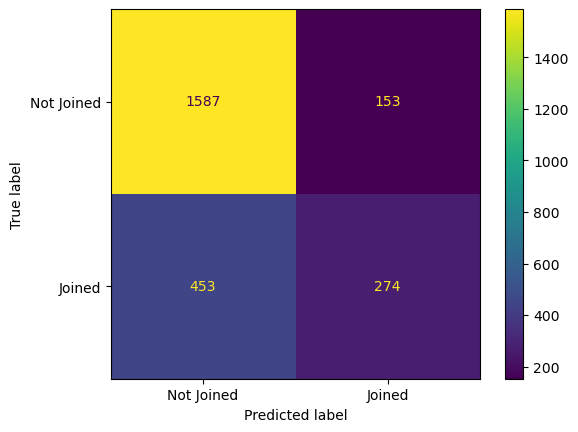

In [632]:
cm_plot.plot();

# Model is not great because FP is more - people leaving are not predicted correctly hence it is important

In [633]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [634]:
recall_score(y_df.actual, y_df.predicted)

0.9120689655172414

In [635]:
print(classification_report(y_df.actual, y_df.predicted))

# We only look at "1" value - here the recall is bad!

              precision    recall  f1-score   support

           0       0.64      0.38      0.47       727
           1       0.78      0.91      0.84      1740

    accuracy                           0.75      2467
   macro avg       0.71      0.64      0.66      2467
weighted avg       0.74      0.75      0.73      2467



## How to evaluate and compare models?

In [637]:
y_pred_probs = logreg_v1.predict_proba(X_test)

In [638]:
y_pred_probs[0:5]

array([[0.00450599, 0.99549401],
       [0.19083623, 0.80916377],
       [0.12241734, 0.87758266],
       [0.23581483, 0.76418517],
       [0.38583386, 0.61416614]])

In [639]:
y_pred_probs[:, 1]

array([0.99549401, 0.80916377, 0.87758266, ..., 0.99347992, 0.85381685,
       0.82693619])

In [640]:
y_df['pred_probs'] = y_pred_probs[:, 1]

In [641]:
y_df.sample(10, random_state=20)

,actual,predicted,pred_probs
2531,1,1,0.705290
472,0,1,0.855956
85,1,0,0.450183
3860,0,0,0.488397
5369,1,1,0.718619
10059,0,1,0.503049
9867,1,1,0.668519
5176,1,1,0.864171
88,1,1,0.824754
3413,0,1,0.524755


### Finding the probability distribution of predicted probabilities

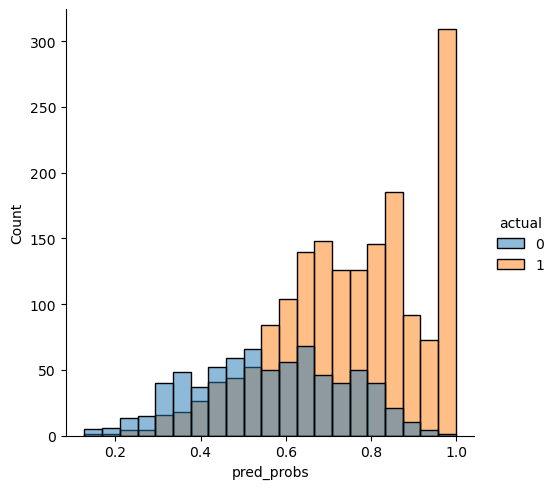

In [643]:
sn.displot(data = y_df,
           x = 'pred_probs',
           hue = 'actual');

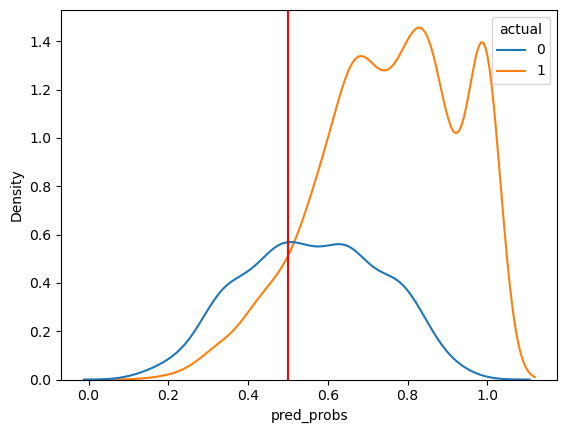

In [644]:
sn.kdeplot(data = y_df,
           x = 'pred_probs',
           hue = 'actual');
plt.axvline(x = 0.5, color = 'r', label = 'cut off');

### What happens if we change the cutoff probabilities?

- What happens if cutoff probability is 0.0
- What happens if cutoff probability is 1.0

In [646]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

In [647]:
roc_auc_score(y_df.actual, y_df.pred_probs)

0.7816645322455691

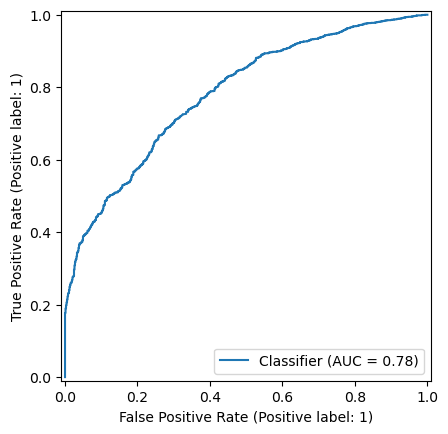

In [648]:
RocCurveDisplay.from_predictions(y_df.actual, y_df.pred_probs);

### Changing the cutoff probabilities

In [650]:
# Predict probabilities on the test set
y_prob = logreg_v1.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
y_true = y_test  # Actual test labels

In [651]:
from sklearn.metrics import confusion_matrix

# Assuming y_true is your true labels and y_prob is the predicted probabilities from your logistic regression model

# Cost values
cost_false_positive = 3  # Cost for a false positive
cost_false_negative = 1  # Cost for a false negative

# Function to calculate cost for a given threshold
def calculate_cost(threshold, y_true, y_prob):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = (fp * cost_false_positive) + (fn * cost_false_negative)
    return total_cost

# Generating thresholds
thresholds = np.linspace(0, 1, 100)

# Calculate cost for each threshold
costs = [calculate_cost(t, y_true, y_prob) for t in thresholds]

# Find the threshold with the minimum cost
optimal_threshold = thresholds[np.argmin(costs)]

# Output the optimal threshold
print(f'The optimal probability threshold is: {optimal_threshold:.2f}')


The optimal probability threshold is: 0.78


In [652]:
y_df['new_preds'] = y_df.pred_probs.map(lambda x: 1 if x > 0.78 else 0)

In [653]:
cm_new = confusion_matrix(y_df.actual, y_df.new_preds, labels = [1,0])

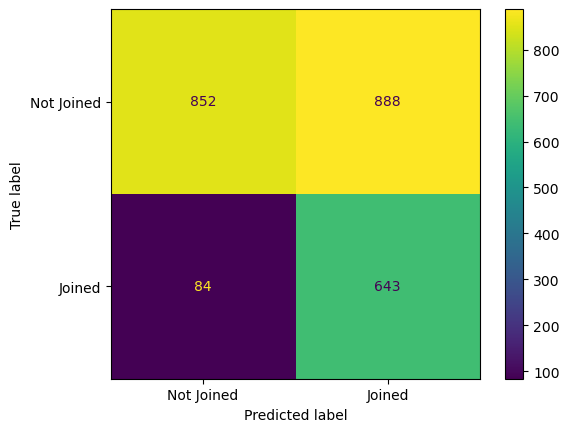

In [654]:
ConfusionMatrixDisplay(cm_new, display_labels=['Not Joined', 'Joined']).plot();

In [655]:
print(classification_report(y_df.actual, y_df.new_preds))

              precision    recall  f1-score   support

           0       0.42      0.88      0.57       727
           1       0.91      0.49      0.64      1740

    accuracy                           0.61      2467
   macro avg       0.67      0.69      0.60      2467
weighted avg       0.77      0.61      0.62      2467

